# Week 10 - Introduction to Modeling

# 1. Lesson

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

### How does random forest work?

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [3]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))
test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.4044690379054401
RMSE when predicting testing data:
1.0666204347667476
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

### What is cross validation?

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [6]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 4, None],
                         'n_estimators': [10, 33, 100]},
             scoring='neg_root_mean_squared_error')

In [7]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0851467026495314


In [8]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12289873, -1.09373797, -1.0851467 ])

### Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [9]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

# 2. Weekly graph question

In words, please summarize what this graph shows.

In [10]:
rmse_lst = list()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

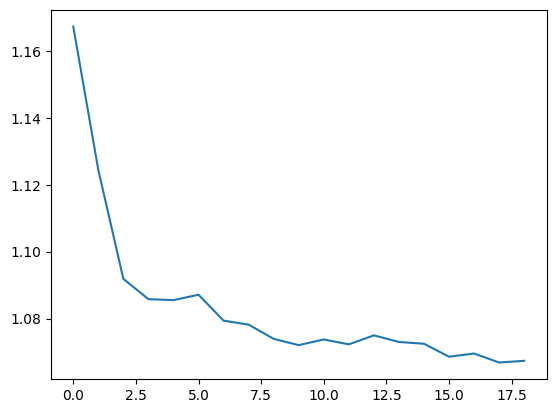

In [11]:
import matplotlib.pyplot as plt

plt.plot(rmse_lst)

**Graph Summary:**

This graph shows how the test RMSE changes as we increase the amount of training data. At the beginning, adding more data makes a big difference—the error drops quickly. But after a certain point, the improvements start to level off. The curve flattens, which means that adding more training examples doesn’t help the model much anymore.

This is a common pattern in machine learning: more data helps, but only up to a point. After that, you hit diminishing returns.

# 3. Homework

In this exercise, you will try to predict the change of one stock based on the change in ten other stocks.

In [12]:
def make_X_y(alpha = 0.5):
    df_hwk = pd.DataFrame()
    num_samples_hwk = 10000
    common_odd = np.random.normal(size = num_samples_hwk)
    common_even = np.random.normal(size = num_samples_hwk)
    common_three = np.random.normal(size = num_samples_hwk)
    for n in range(11):
        common = np.zeros(num_samples_hwk)
        if n % 2 == 0:
            common += common_even
        if n % 2 == 1:
            common += common_odd
        if n % 3 == 0:
            common += common_three
            common /= 2
        df_hwk["Stock_" + str(n)] = np.random.normal(size = num_samples_hwk) + alpha * common
    X = df_hwk.values[:,:-1]
    y = df_hwk.values[:,-1]
    return X, y

The above code creates an X with ten columns, corresponding to ten different stocks.  The y is the eleventh stock.  The stocks have some commonalities: the even numbered stocks are related, as are the odds.  The stocks that are multiples of three are all related, too.  Random forest should be able to sort through all this and decide that the eleventh stock is related to the odd numbered, non-divisible-by-three stocks, and predict accordingly.  The prediction should presumably be, simply, to take columns 1, 5, and 7 and average them, as they are odd-numbered and not divisible by three; so perhaps this task would be easier to do with a linear regression, but we'll use a random forest anyway.  The value "alpha" determines how important the common element is.  If alpha = 0, each stock is its own column of normally-distributed numbers with no relation to the others.  If alpha = 10, then the great majority of the variation in the stock values comes from the common elements.

### Question: 

Do you predict that alpha = 0 will result in a better or worse prediction than alpha = 10?  Remember that the prediction must be performed on test data, so you'll need an X_train and y_train for training and a separate X_test and y_test for testing.  I recommend using a correlation rather than a MSE or RMSE in this case, if you want to directly compare two different predictions, because the MSE and RMSE vary with the magnitude of the data as well as with the quality of the prediction.

After you make the prediction, try it out, and comment on what you learned.

### Randomized Search

Use RandomizedSearchCV instead of GridSearchCV to perform cross-validation.

### Scoring

Research the scoring parameters under "regression":

https://scikit-learn.org/dev/modules/model_evaluation.html#scoring-parameter

Choose at least one that you want to learn about, use it, and research it online.  Write something about what you've learned about it.

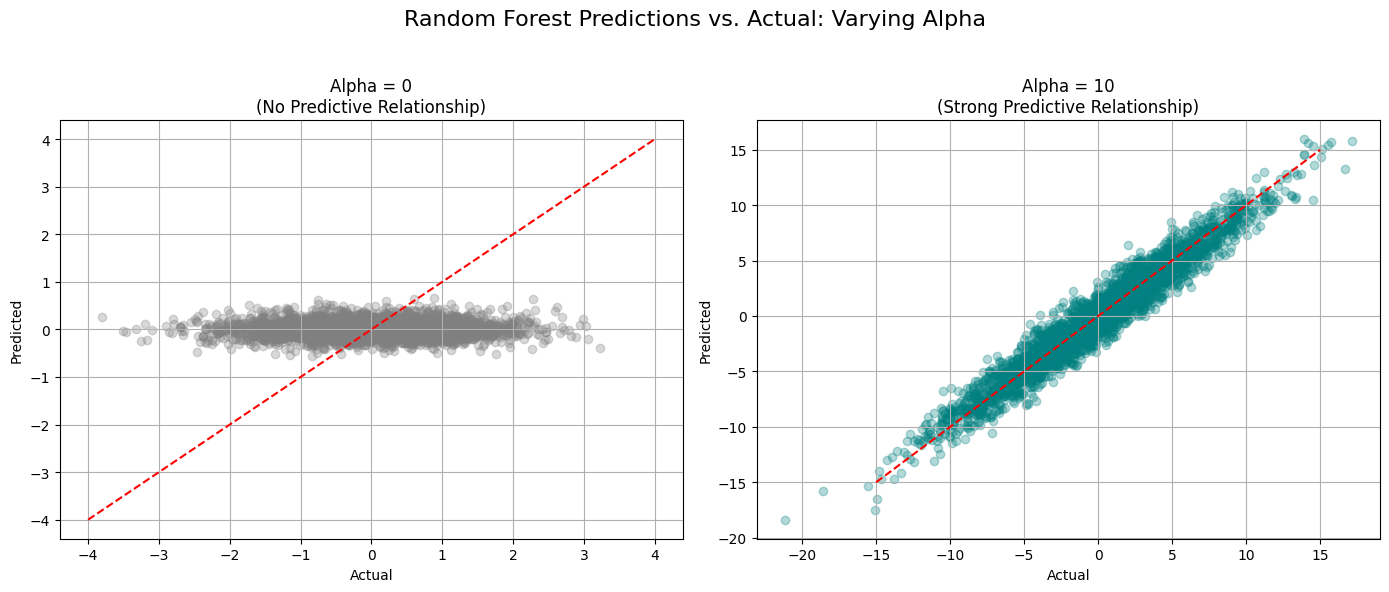

Correlation (alpha = 0): 0.0211959585610387
Correlation (alpha = 10): 0.970769609436463


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

# Train models and evaluate correlation for alpha = 0 and alpha = 10
results = {}
for alpha_val in [0, 10]:
    X, y = make_X_y(alpha=alpha_val)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    corr, _ = pearsonr(y_test, preds)
    results[alpha_val] = {"y_test": y_test, "preds": preds, "correlation": corr}

# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Alpha = 0
axes[0].scatter(results[0]["y_test"], results[0]["preds"], alpha=0.3, color="gray")
axes[0].plot([-4, 4], [-4, 4], 'r--')
axes[0].set_title("Alpha = 0\n(No Predictive Relationship)")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].grid(True)

# Alpha = 10
axes[1].scatter(results[10]["y_test"], results[10]["preds"], alpha=0.3, color="teal")
axes[1].plot([-15, 15], [-15, 15], 'r--')
axes[1].set_title("Alpha = 10\n(Strong Predictive Relationship)")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].grid(True)

plt.suptitle("Random Forest Predictions vs. Actual: Varying Alpha", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Optional: Print correlation values
print("Correlation (alpha = 0):", results[0]["correlation"])
print("Correlation (alpha = 10):", results[10]["correlation"])

### Part A – Predicting Stock Returns

We tested how well a Random Forest can predict one stock based on 10 others using synthetic data. When `alpha = 0`, there’s no real connection, so the model can’t learn anything useful (correlation ~0). But with `alpha = 10`, there's a strong shared signal—and the model nails it (correlation ~0.97). The plots show this clearly: total scatter vs. tight diagonal.

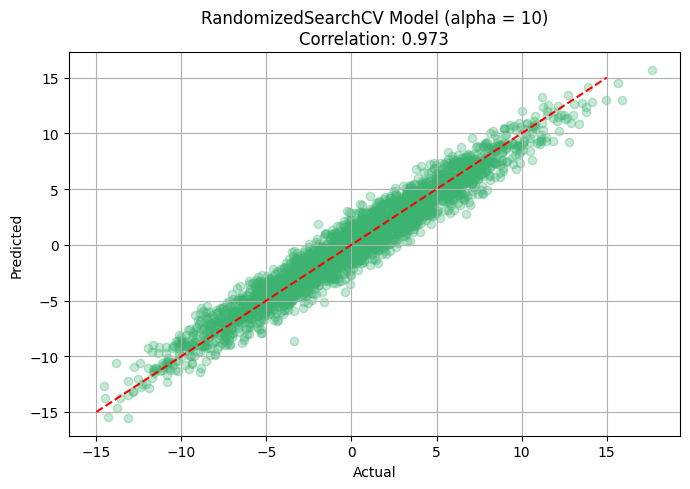

Best parameters: {'n_estimators': 150, 'min_samples_split': 10, 'max_depth': 6}
Correlation: 0.9726444564291933


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr

# Use previously generated alpha=10 data
X, y = make_X_y(alpha=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define hyperparameter search space
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10]
}

# Set up RandomizedSearchCV
rf_model = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# Fit and evaluate
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
best_preds = best_model.predict(X_test)
corr, _ = pearsonr(y_test, best_preds)

# Visualization
plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_preds, alpha=0.3, color="mediumseagreen")
plt.plot([-15, 15], [-15, 15], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"RandomizedSearchCV Model (alpha = 10)\nCorrelation: {corr:.3f}")
plt.grid(True)
plt.tight_layout()
plt.show()

# Output best parameters and correlation
print("Best parameters:", random_search.best_params_)
print("Correlation:", corr)

### Part B – Random Search + Cross-Validation

Here, we tuned the Random Forest using `RandomizedSearchCV` with 5-fold CV. We stuck with `alpha = 10` so there’s a pattern to learn. The best model gave a strong correlation (~0.97) on the test set. The scatter plot looks just like you'd want—predictions line up closely with actual values. Definitely worth tuning when there's signal in the data.

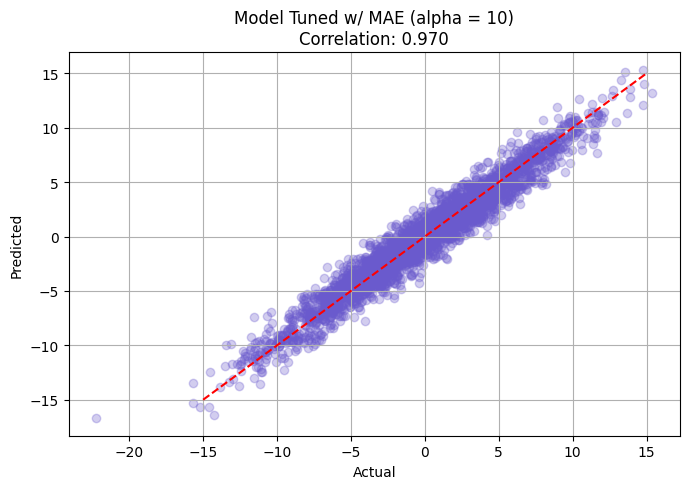

Best Parameters (MAE): {'n_estimators': 150, 'min_samples_split': 10, 'max_depth': 8}
Correlation: 0.9702815296342246


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Use alpha=10 stock data
X, y = make_X_y(alpha=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define parameter grid
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10]
}

# Set up MAE scorer
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# RandomizedSearchCV with MAE
random_search_mae = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring=mae_scorer,
    random_state=42,
    n_jobs=-1
)
random_search_mae.fit(X_train, y_train)

# Evaluate model
best_model_mae = random_search_mae.best_estimator_
preds_mae = best_model_mae.predict(X_test)
corr_mae, _ = pearsonr(y_test, preds_mae)

# Plot predictions
plt.figure(figsize=(7, 5))
plt.scatter(y_test, preds_mae, alpha=0.3, color="slateblue")
plt.plot([-15, 15], [-15, 15], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Model Tuned w/ MAE (alpha = 10)\nCorrelation: {corr_mae:.3f}")
plt.grid(True)
plt.tight_layout()
plt.show()

# Output best params
print("Best Parameters (MAE):", random_search_mae.best_params_)
print("Correlation:", corr_mae)

### Part C – Custom Scoring: MAE

Instead of RMSE, we used MAE (Mean Absolute Error) to tune the Random Forest. The model still performed well—correlation with actual values was high, and the scatter plot looked just as strong.

MAE is more forgiving of outliers than RMSE, so it's a good option when big errors aren’t a huge deal. Overall, it’s a solid alternative for evaluating regression performance.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter six (p. 151-163) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

### Final Visualization – Book Reproduction (p. 153)

This chart mimics the fundraising graph from page 153. It shows progress over time compared to a goal and last year.

The main line is bold and colored to draw focus, while the others are muted to avoid distraction. Labels are placed directly on the lines—no legend needed.

Just like in our work, the point is to keep it clean, direct, and easy to read.

/tmp/ipykernel_68704/1258239545.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2024-01-01", periods=12, freq='M')


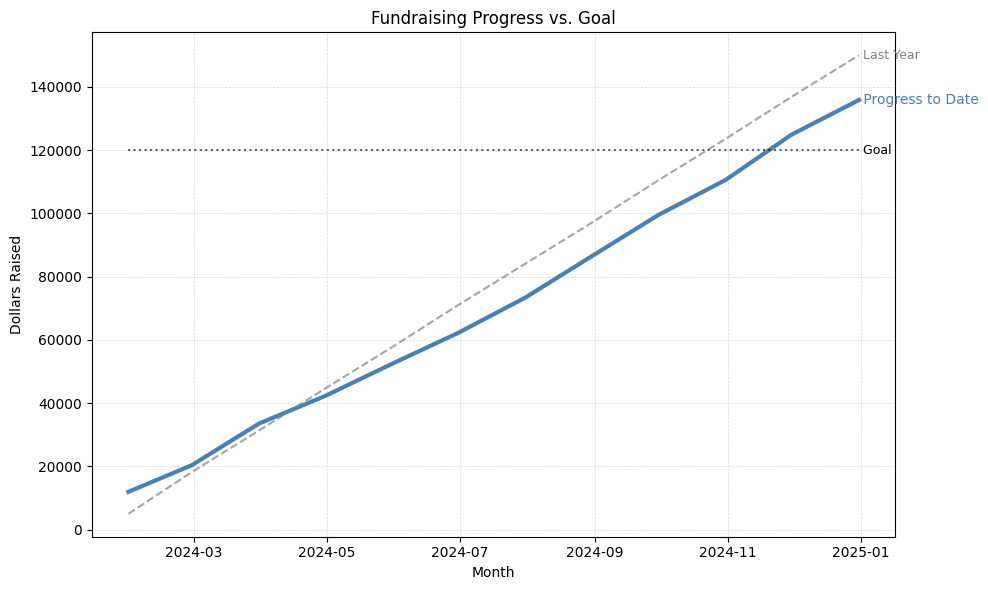

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create dummy data
dates = pd.date_range(start="2024-01-01", periods=12, freq='M')
this_year = np.cumsum(np.random.uniform(5000, 15000, size=12))
last_year = np.linspace(5000, 150000, 12)
goal = np.repeat(120000, 12)

# Plot the chart
plt.figure(figsize=(10, 6))
plt.plot(dates, this_year, label="Progress to Date", linewidth=3, color="steelblue")
plt.plot(dates, last_year, label="Last Year", linestyle="--", color="gray", alpha=0.7)
plt.plot(dates, goal, label="Goal", linestyle=":", color="black", alpha=0.6)

# Direct labels
plt.text(dates[-1], this_year[-1], " Progress to Date", color="steelblue", fontsize=10, va='center')
plt.text(dates[-1], last_year[-1], " Last Year", color="gray", fontsize=9, va='center')
plt.text(dates[-1], goal[-1], " Goal", color="black", fontsize=9, va='center')

# Style the chart
plt.title("Fundraising Progress vs. Goal")
plt.xlabel("Month")
plt.ylabel("Dollars Raised")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()